# A* Comparison Notebook

This notebook compares A*, Dijkstra, BFS, DFS, and Greedy Best-First on the same city network, then shows a dark-mode grid plot of each algorithm path separately.

City: Bengaluru, Karnataka
From: MG Road (12.9757, 77.6011)
To  : Jayanagar (12.9250, 77.5838)



,algorithm,found_path,path_nodes,total_cost_s,total_cost_min,explored_nodes,runtime_ms
0,A*,True,4,950.78,15.85,7,0.157
1,Dijkstra,True,4,950.78,15.85,20,0.023
2,BFS,True,4,950.78,15.85,20,0.012
4,Greedy Best-First,True,4,950.78,15.85,14,0.019
3,DFS,True,5,1246.68,20.78,10,0.004


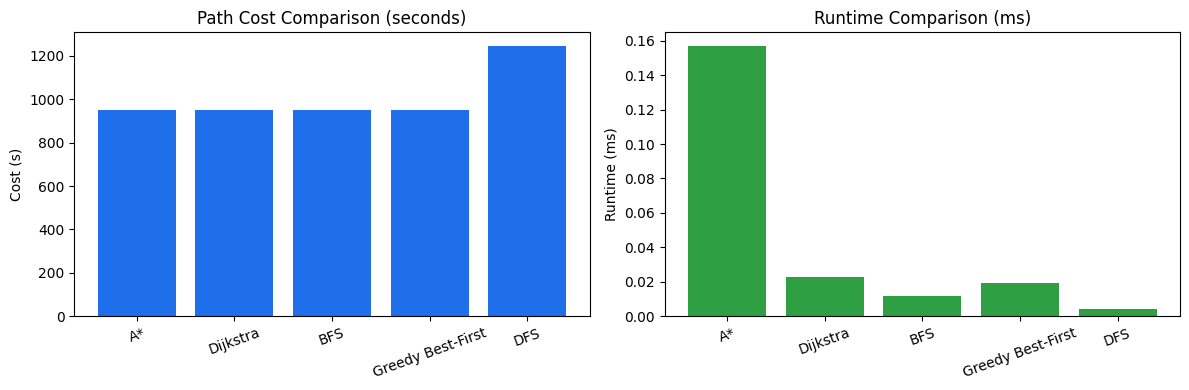


A* path (4 nodes):
MG Road -> Majestic Bus Stand -> KR Market -> Jayanagar

Dijkstra path (4 nodes):
MG Road -> Majestic Bus Stand -> KR Market -> Jayanagar

BFS path (4 nodes):
MG Road -> Majestic Bus Stand -> KR Market -> Jayanagar

DFS path (5 nodes):
MG Road -> Majestic Bus Stand -> Vijayanagar -> Banashankari -> Jayanagar

Greedy Best-First path (4 nodes):
MG Road -> Majestic Bus Stand -> KR Market -> Jayanagar


In [1]:
import heapq
import time
from collections import deque

import pandas as pd
import matplotlib.pyplot as plt
from astar_router import RoadNetwork, AStarEngine

# Ensure a network and source/destination exist.
if 'net' not in globals() or net is None:
    net = RoadNetwork('Karnataka', 'Bengaluru', data_dir='india_road_data')
if 'src' not in globals() or 'dst' not in globals() or src not in net.nodes or dst not in net.nodes:
    all_ids = list(net.nodes.keys())
    src, dst = all_ids[0], all_ids[len(all_ids)//2]


def build_min_edge_cost_map(network):
    edge_cost = {}
    for u, nbs in network.adj.items():
        for nb in nbs:
            v, c = nb['to'], float(nb['cost'])
            key = (u, v)
            if key not in edge_cost or c < edge_cost[key]:
                edge_cost[key] = c
    return edge_cost


def path_cost(path, edge_cost):
    if not path or len(path) < 2:
        return 0.0 if path else float('inf')
    total = 0.0
    for i in range(len(path) - 1):
        c = edge_cost.get((path[i], path[i + 1]))
        if c is None:
            return float('inf')
        total += c
    return total


def reconstruct_path(came_from, source, target):
    if target == source:
        return [source]
    if target not in came_from:
        return []
    p = [target]
    cur = target
    while cur != source:
        cur = came_from[cur]
        p.append(cur)
    p.reverse()
    return p


def run_astar(network, source, target):
    t0 = time.perf_counter()
    engine = AStarEngine(network, source, target)
    ms = (time.perf_counter() - t0) * 1000
    explored = 0
    for st in engine.steps:
        if st.get('event') == 'visit':
            explored += 1
    return {
        'algorithm': 'A*',
        'found': bool(engine.path),
        'path': engine.path,
        'cost': float(engine.cost) if engine.path else float('inf'),
        'explored_nodes': explored,
        'runtime_ms': ms,
    }


def run_dijkstra(network, source, target):
    t0 = time.perf_counter()
    dist = {n: float('inf') for n in network.nodes}
    dist[source] = 0.0
    came = {}
    pq = [(0.0, source)]
    visited = set()

    while pq:
        d, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)
        if u == target:
            break
        for nb in network.adj[u]:
            v, w = nb['to'], float(nb['cost'])
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                came[v] = u
                heapq.heappush(pq, (nd, v))

    path = reconstruct_path(came, source, target)
    ms = (time.perf_counter() - t0) * 1000
    return {
        'algorithm': 'Dijkstra',
        'found': len(path) > 0,
        'path': path,
        'cost': dist[target] if path else float('inf'),
        'explored_nodes': len(visited),
        'runtime_ms': ms,
    }


def run_bfs(network, source, target, edge_cost):
    t0 = time.perf_counter()
    q = deque([source])
    seen = {source}
    came = {}

    while q:
        u = q.popleft()
        if u == target:
            break
        for nb in network.adj[u]:
            v = nb['to']
            if v not in seen:
                seen.add(v)
                came[v] = u
                q.append(v)

    path = reconstruct_path(came, source, target)
    ms = (time.perf_counter() - t0) * 1000
    return {
        'algorithm': 'BFS',
        'found': len(path) > 0,
        'path': path,
        'cost': path_cost(path, edge_cost),
        'explored_nodes': len(seen),
        'runtime_ms': ms,
    }


def run_dfs(network, source, target, edge_cost):
    t0 = time.perf_counter()
    stack = [source]
    seen = {source}
    came = {}

    while stack:
        u = stack.pop()
        if u == target:
            break
        for nb in network.adj[u]:
            v = nb['to']
            if v not in seen:
                seen.add(v)
                came[v] = u
                stack.append(v)

    path = reconstruct_path(came, source, target)
    ms = (time.perf_counter() - t0) * 1000
    return {
        'algorithm': 'DFS',
        'found': len(path) > 0,
        'path': path,
        'cost': path_cost(path, edge_cost),
        'explored_nodes': len(seen),
        'runtime_ms': ms,
    }


def run_greedy_best_first(network, source, target, edge_cost):
    t0 = time.perf_counter()
    pq = [(network.heuristic(source, target), source)]
    seen = {source}
    came = {}

    while pq:
        _, u = heapq.heappop(pq)
        if u == target:
            break
        for nb in network.adj[u]:
            v = nb['to']
            if v not in seen:
                seen.add(v)
                came[v] = u
                h = network.heuristic(v, target)
                heapq.heappush(pq, (h, v))

    path = reconstruct_path(came, source, target)
    ms = (time.perf_counter() - t0) * 1000
    return {
        'algorithm': 'Greedy Best-First',
        'found': len(path) > 0,
        'path': path,
        'cost': path_cost(path, edge_cost),
        'explored_nodes': len(seen),
        'runtime_ms': ms,
    }


edge_cost_map = build_min_edge_cost_map(net)
results = [
    run_astar(net, src, dst),
    run_dijkstra(net, src, dst),
    run_bfs(net, src, dst, edge_cost_map),
    run_dfs(net, src, dst, edge_cost_map),
    run_greedy_best_first(net, src, dst, edge_cost_map),
]

rows = []
for r in results:
    c = r['cost']
    rows.append({
        'algorithm': r['algorithm'],
        'found_path': r['found'],
        'path_nodes': len(r['path']) if r['path'] else 0,
        'total_cost_s': None if not r['found'] or c == float('inf') else round(c, 2),
        'total_cost_min': None if not r['found'] or c == float('inf') else round(c / 60.0, 2),
        'explored_nodes': r['explored_nodes'],
        'runtime_ms': round(r['runtime_ms'], 3),
    })

compare_df = pd.DataFrame(rows).sort_values(['found_path', 'total_cost_s'], ascending=[False, True])

s_node = net.nodes[src]
d_node = net.nodes[dst]
print(f"City: {net.city}, {net.state}")
print(f"From: {s_node['name']} ({s_node['lat']:.4f}, {s_node['lon']:.4f})")
print(f"To  : {d_node['name']} ({d_node['lat']:.4f}, {d_node['lon']:.4f})")
print()
display(compare_df)

# Quick visualization: travel cost and runtime for methods that found a path.
plot_df = compare_df[compare_df['found_path'] == True].copy()
if len(plot_df) > 0:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].bar(plot_df['algorithm'], plot_df['total_cost_s'], color='#1f6feb')
    ax[0].set_title('Path Cost Comparison (seconds)')
    ax[0].set_ylabel('Cost (s)')
    ax[0].tick_params(axis='x', rotation=20)

    ax[1].bar(plot_df['algorithm'], plot_df['runtime_ms'], color='#2ea043')
    ax[1].set_title('Runtime Comparison (ms)')
    ax[1].set_ylabel('Runtime (ms)')
    ax[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()

# Optional: inspect each found path as node names.
for r in results:
    if not r['found']:
        print(f"\n{r['algorithm']}: no path found")
        continue
    names = [net.nodes[nid]['name'] for nid in r['path']]
    print(f"\n{r['algorithm']} path ({len(names)} nodes):")
    print(' -> '.join(names[:8]) + (' -> ...' if len(names) > 8 else ''))

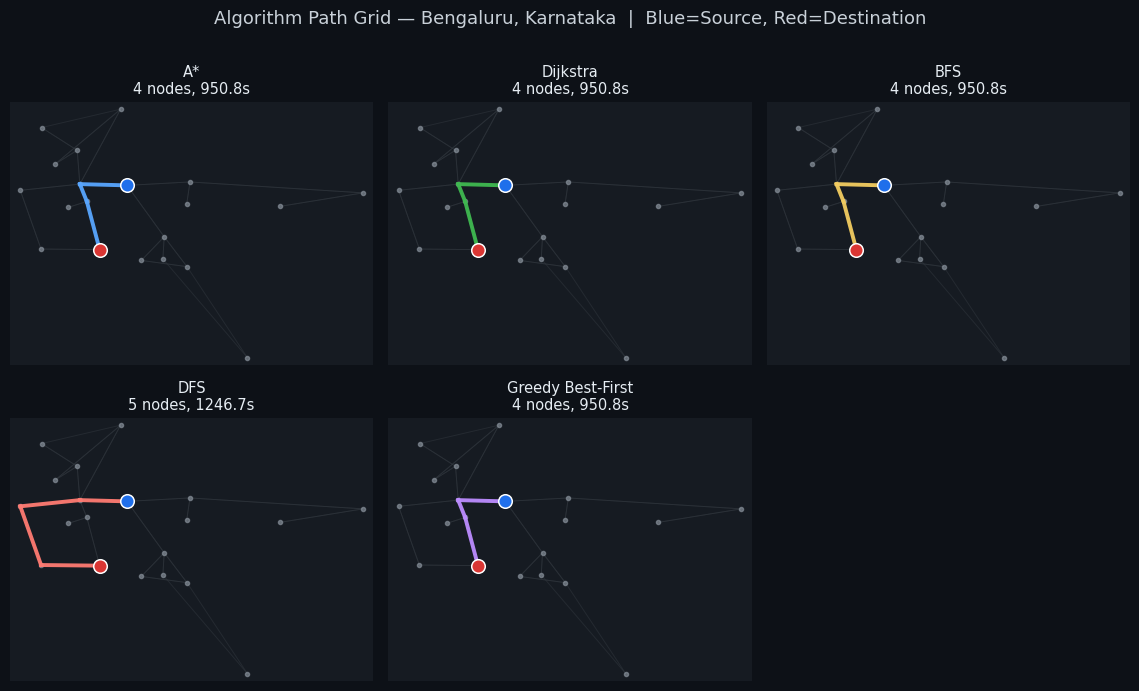

In [ ]:
# Grid view: one subplot per algorithm path (dark mode).
# Requires: net, src, dst, results (from previous cell).

import math

if 'results' not in globals() or 'net' not in globals():
    raise RuntimeError('Run the previous cell first so results and net are available.')

algo_colors = {
    'A*': '#58a6ff',
    'Dijkstra': '#3fb950',
    'BFS': '#f2cc60',
    'DFS': '#ff7b72',
    'Greedy Best-First': '#bc8cff',
}

# Build a unique directed-edge geometry map.
edge_xy = {}
for e in net.edges:
    u, v = e['u'], e['v']
    if u in net.nodes and v in net.nodes and (u, v) not in edge_xy:
        nu, nv = net.nodes[u], net.nodes[v]
        edge_xy[(u, v)] = ((nu['x'], nu['y']), (nv['x'], nv['y']))

all_x = [n['x'] for n in net.nodes.values()]
all_y = [n['y'] for n in net.nodes.values()]
margin = 0.03
xmin, xmax = min(all_x) - margin, max(all_x) + margin
ymin, ymax = min(all_y) - margin, max(all_y) + margin

n_algos = len(results)
ncols = 3
nrows = math.ceil(n_algos / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(11.5, 3.4 * nrows))
fig.patch.set_facecolor('#0d1117')

# Normalize axes container for easy indexing.
if nrows == 1 and ncols == 1:
    axes = [[axes]]
elif nrows == 1:
    axes = [axes]
elif ncols == 1:
    axes = [[ax] for ax in axes]

sn = net.nodes[src]
dn = net.nodes[dst]

for idx, r in enumerate(results):
    rr = idx // ncols
    cc = idx % ncols
    ax = axes[rr][cc]

    ax.set_facecolor('#161b22')

    # Base network in each panel.
    for (u, v), ((x0, y0), (x1, y1)) in edge_xy.items():
        ax.plot([x0, x1], [y0, y1], color='#30363d', linewidth=0.7, alpha=0.55, zorder=1)

    # Algorithm path.
    if r.get('found') and r.get('path') and len(r['path']) >= 2:
        p = r['path']
        color = algo_colors.get(r['algorithm'], '#e6edf3')
        for i in range(len(p) - 1):
            uv = (p[i], p[i + 1])
            if uv in edge_xy:
                (x0, y0), (x1, y1) = edge_xy[uv]
                ax.plot([x0, x1], [y0, y1], color=color, linewidth=2.8, alpha=0.95, zorder=3)

    # Nodes + source/destination markers.
    ax.scatter(all_x, all_y, s=9, c='#8b949e', alpha=0.65, zorder=2)
    ax.scatter([sn['x']], [sn['y']], s=95, c='#1f6feb', edgecolors='white', linewidths=1.1, zorder=4)
    ax.scatter([dn['x']], [dn['y']], s=95, c='#da3633', edgecolors='white', linewidths=1.1, zorder=4)

    title = r['algorithm']
    if r.get('found'):
        title += f"\n{len(r['path'])} nodes, {r['cost']:.1f}s"
    else:
        title += '\nNo path'
    ax.set_title(title, fontsize=10.5, color='#e6edf3')

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

# Hide any unused subplots (if grid has extra slots).
for idx in range(n_algos, nrows * ncols):
    rr = idx // ncols
    cc = idx % ncols
    blank_ax = axes[rr][cc]
    blank_ax.set_facecolor('#0d1117')
    blank_ax.axis('off')

fig.suptitle(
    f'Algorithm Path Grid — {net.city}, {net.state}  |  Blue=Source, Red=Destination',
    fontsize=13,
    color='#c9d1d9',
    y=1.01,
)
plt.tight_layout()
plt.show()